In [6]:
import sys, os

# Add project root (one level up from notebooks folder)
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from lstm_model import prepare_data, build_lstm_model, train_lstm_model, save_lstm_model
from utils import clean_text


In [8]:
import pandas as pd
from lstm_model import prepare_data, build_lstm_model, train_lstm_model, save_lstm_model
from utils import clean_text

# Load dataset
df = pd.read_csv("/Users/rahulmanchanda/Desktop/sentimen-analysis-nlp/data/IMDB Dataset.csv")  # replace with your path
texts = df['review'].tolist()
labels = df['sentiment'].tolist()


In [9]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [10]:
# Split, tokenize, pad, and encode labels
X_train, X_test, y_train, y_test, tokenizer, label_encoder = prepare_data(
    texts, labels, test_size=0.2
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")


Training samples: 40000, Test samples: 10000


In [12]:
model = build_lstm_model()
model.build(input_shape=(None, X_train.shape[1]))  # X_train is your padded sequence
model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,641 (4.15 MB)

 Trainable params: 1,088,641 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = train_lstm_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=64,   
    epochs=5         
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.8271 - loss: 0.3801 - val_accuracy: 0.8579 - val_loss: 0.3437
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.9069 - loss: 0.2444 - val_accuracy: 0.8842 - val_loss: 0.2892
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.9293 - loss: 0.1946 - val_accuracy: 0.8807 - val_loss: 0.2953
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.9453 - loss: 0.1519 - val_accuracy: 0.8746 - val_loss: 0.3351


In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Predict probabilities on test set
y_pred_prob = model.predict(X_test)

# Convert probabilities to 0/1
y_pred = np.round(y_pred_prob).astype(int).flatten()

y_test_encoded = y_test  # no transformation needed


# Accuracy
acc = accuracy_score(y_test_encoded, y_pred)
print(f"[INFO] Test Accuracy: {acc:.4f}\n")

# Detailed classification report
print("[INFO] Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
[INFO] Test Accuracy: 0.8842

[INFO] Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.84      0.88      4961
    positive       0.86      0.93      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [15]:
print(y_test[:5])


[1 1 0 1 0]


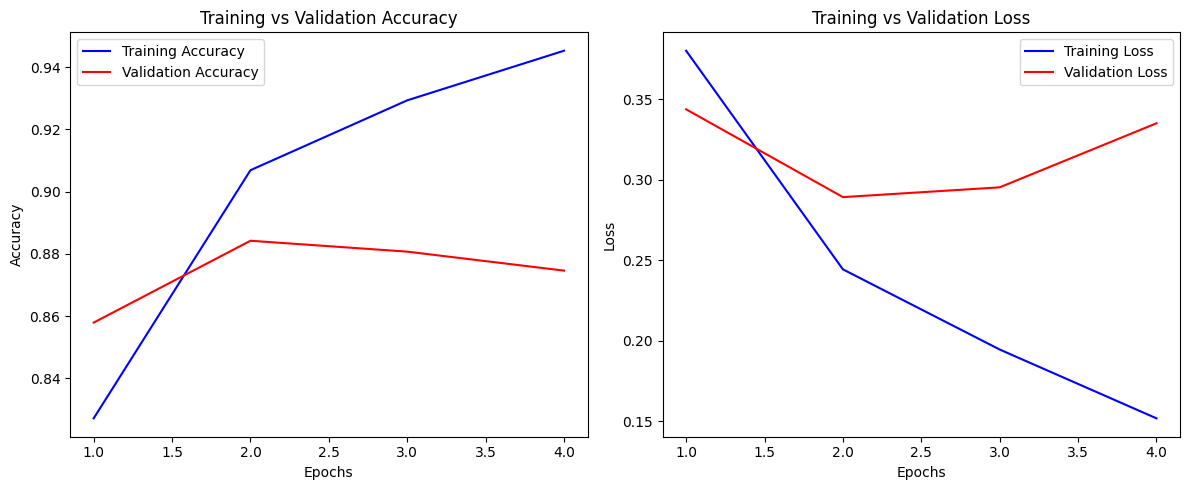

In [17]:
import matplotlib.pyplot as plt

# Extract metrics from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
import os
from lstm_model import save_lstm_model

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Paths to save
model_path = "models/lstm_full_model.h5"
tok_path = "models/lstm_full_tokenizer.pkl"
le_path = "models/lstm_full_labelencoder.pkl"

# Save everything
save_lstm_model(
    model,
    tokenizer,      # your fitted tokenizer
    label_encoder,  # your fitted label encoder
    model_path=model_path,
    tok_path=tok_path,
    le_path=le_path
)

print(f"[INFO] LSTM model saved to {model_path}")
print(f"[INFO] Tokenizer saved to {tok_path}")
print(f"[INFO] Label Encoder saved to {le_path}")


[INFO] Model saved to models/lstm_full_model.h5, tokenizer to models/lstm_full_tokenizer.pkl, label encoder to models/lstm_full_labelencoder.pkl
[INFO] LSTM model saved to models/lstm_full_model.h5
[INFO] Tokenizer saved to models/lstm_full_tokenizer.pkl
[INFO] Label Encoder saved to models/lstm_full_labelencoder.pkl
